Class Distribution: {'NORMAL': 1341, 'PNEUMONIA': 3875}


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s] 



--- Training Version 1 ---
Epoch 1/10 - Loss: 0.4693, Acc: 77.36%
Epoch 2/10 - Loss: 0.3111, Acc: 88.59%
Epoch 3/10 - Loss: 0.2592, Acc: 90.36%
Epoch 4/10 - Loss: 0.2268, Acc: 91.51%
Epoch 5/10 - Loss: 0.2063, Acc: 92.29%
Epoch 6/10 - Loss: 0.1941, Acc: 92.64%
Epoch 7/10 - Loss: 0.1866, Acc: 92.91%
Epoch 8/10 - Loss: 0.1784, Acc: 92.94%
Epoch 9/10 - Loss: 0.1720, Acc: 93.33%
Epoch 10/10 - Loss: 0.1719, Acc: 92.98%

--- Training Version 2 ---
Epoch 1/10 - Loss: 0.2542, Acc: 89.65%
Epoch 2/10 - Loss: 0.1628, Acc: 93.77%
Epoch 3/10 - Loss: 0.1439, Acc: 94.44%
Epoch 4/10 - Loss: 0.1348, Acc: 94.86%
Epoch 5/10 - Loss: 0.1278, Acc: 95.17%
Epoch 6/10 - Loss: 0.1199, Acc: 95.53%
Epoch 7/10 - Loss: 0.1217, Acc: 95.23%
Epoch 8/10 - Loss: 0.1155, Acc: 95.55%
Epoch 9/10 - Loss: 0.1121, Acc: 95.46%
Epoch 10/10 - Loss: 0.1113, Acc: 95.82%


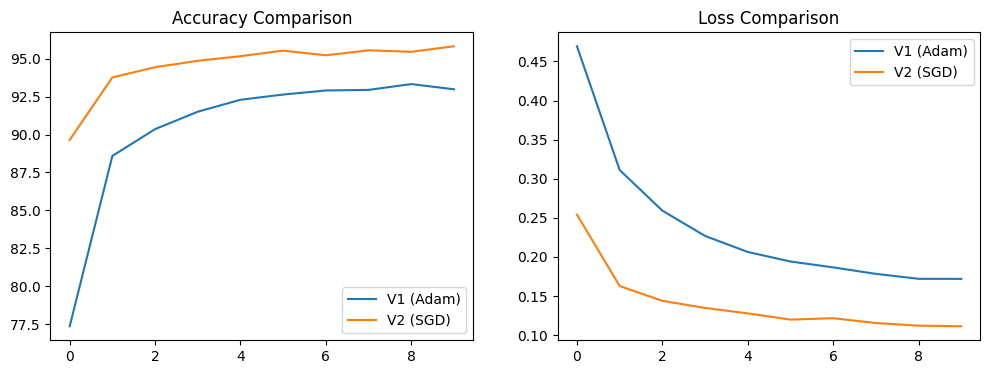


Version 1 (Adam) Accuracy: 84.46%
Version 2 (SGD) Accuracy: 78.85%


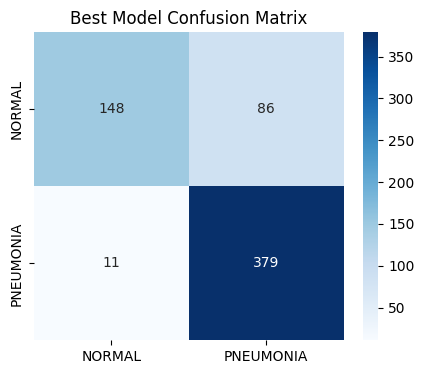

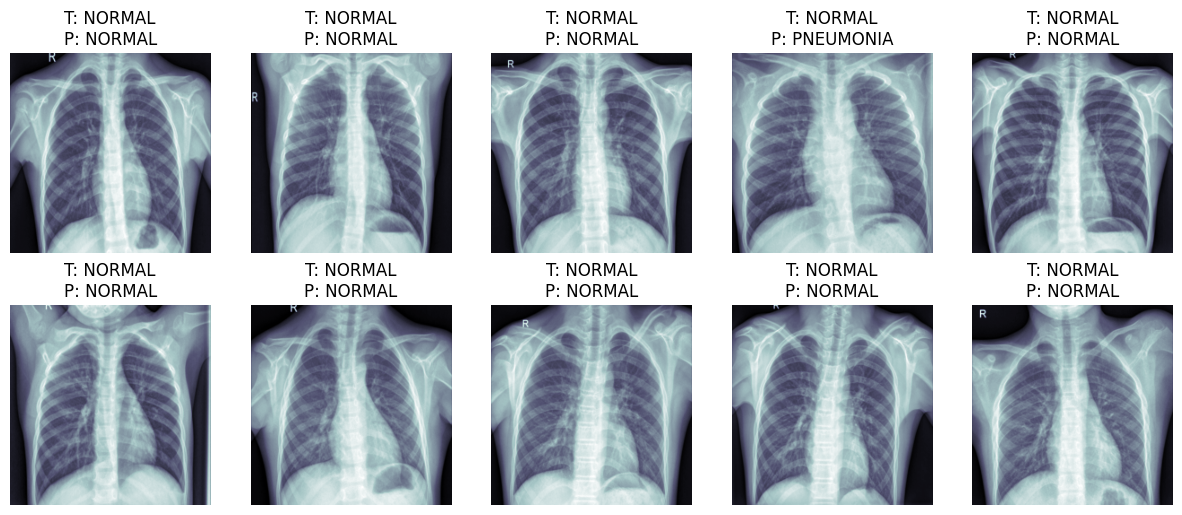


Analiz: Adam (V1) adətən transfer learning-də daha stabil nəticə verir.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

SEED = 20240314 
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

classes = train_dataset.classes
counts = [len([1 for _, label in train_dataset.samples if label == i]) for i in range(len(classes))]
print(f"Class Distribution: {dict(zip(classes, counts))}")

def create_resnet18():
    model = models.resnet18(weights='IMAGENET1K_V1')
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(512, 2)
    return model.to(device)


def train_model(name, opt_type, lr, batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = create_resnet18()
    criterion = nn.CrossEntropyLoss()
    

    if opt_type == 'Adam':
        optimizer = optim.Adam(model.fc.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.fc.parameters(), lr=lr, momentum=0.9)
        
    history = {'loss': [], 'acc': []}
    
    print(f"\n--- Training {name} ---")
    for epoch in range(10): # 10 Epochs
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct.double() / len(train_dataset)
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc.item() * 100)
        print(f"Epoch {epoch+1}/10 - Loss: {epoch_loss:.4f}, Acc: {history['acc'][-1]:.2f}%")
        

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    test_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    return model, history, test_acc, all_preds, all_labels



model1, hist1, acc1, preds1, labels1 = train_model("Version 1", "Adam", 0.0001, 32)


model2, hist2, acc2, preds2, labels2 = train_model("Version 2", "SGD", 0.001, 32)




plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist1['acc'], label='V1 (Adam)')
plt.plot(hist2['acc'], label='V2 (SGD)')
plt.title('Accuracy Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist1['loss'], label='V1 (Adam)')
plt.plot(hist2['loss'], label='V2 (SGD)')
plt.title('Loss Comparison')
plt.legend()
plt.show()


print(f"\nVersion 1 (Adam) Accuracy: {acc1:.2f}%")
print(f"Version 2 (SGD) Accuracy: {acc2:.2f}%")


best_preds = preds1 if acc1 > acc2 else preds2
best_labels = labels1 if acc1 > acc2 else labels2
cm = confusion_matrix(best_labels, best_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Best Model Confusion Matrix")
plt.show()


plt.figure(figsize=(15, 6))
best_model = model1 if acc1 > acc2 else model2
for i in range(10):
    img, label = test_dataset[i]
    output = best_model(img.unsqueeze(0).to(device))
    _, pred = torch.max(output, 1)
    plt.subplot(2, 5, i+1)
    plt.imshow(img[0], cmap='bone')
    plt.title(f"T: {classes[label]}\nP: {classes[pred.item()]}")
    plt.axis('off')
plt.show()

print("\nAnalysis: Adam (V1) typically yields more stable results in transfer learning.")